# XSOR Project - task 2: Trending asset into mean reverting asset

Trending assets are those whose prices or returns display a sustained movement in one direction (upward or
downward) over time. Trending assets are typically non-stationary, meaning their statistical properties (e.g.,
mean, variance) evolve over time. This poses challenges for many standard financial analyses, which assume
stationarity.

In this part of the project, instead of analyzing an already mean-reverting asset, our task was to transform a
trending financial asset into one that exhibits mean-reverting behavior through mathematical or statistical normalization
techniques.

# Table of Contents

* **[1 Introduction & Background](#1-introduction--background)**
    * [1.1 Graphical Introduction: Heikin Ashi Candlestick Plot](#1.1-Graphical-Introduction:-Heikin-Ashi-Candlestick-Plot)
    * [1.2 A Metric for Mean Reversion](#12-a-metric-for-mean-reversion)
        * [1.2.1 What is Mean Reversion?](#121-what-is-mean-reversion)
* **[2 Project Overview](#2-project-overview)**
    * [2.1 Focus Areas](#21-focus-areas)
    * [2.2 Approach](#22-approach)
* **[3 Data Preprocessing](#3-data-preprocessing)**
    * [3.1 Filtering the Signal](#31-filtering-the-signal)
* **[4 Statistical Tests for Trend Detection](#4-statistical-tests-for-trend-detection)**
    * [4.1 First Approach: Detrending using Hurst Exponent](#41-first-approach-detrending-using-hurst-exponent)
    * [4.2 Alternative Approach: Mann-Kendall Test](#42-alternative-approach-mann-kendall-test)
* **[5 De-trending Algorithms](#5-de-trending-algorithms)**
    * [5.1 Rolling Mean Method](#51-rolling-mean-method)
        * [5.1.1 Determining the Best Window](#511-determining-the-best-window)
        * [5.1.2 Validation on Toy Model](#512-validation-on-toy-model)
    * [5.2 Fit and Subtract Method (Guided by Mann-Kendall)](#52-fit-and-subtract-method-guided-by-mann-kendall)
* **[6 Comparison and Evaluation](#6-comparison-and-evaluation)**
    * [6.1 Quantitative Comparison (Rolling Mean vs. Fit & Subtract)](#61-quantitative-comparison-rolling-mean-vs-fit--subtract)
    * [6.2 Spectrum Analysis](#62-spectrum-analysis)
    * [6.3 Relative Oscillatory Energy (ROE) Calculation](#63-relative-oscillatory-energy-roe-calculation)
* **[7 Mean Reversion Detection](#7-Mean-Reversion-Detection)**


# 1 Introduction & Background


## 1.1 Graphical Introduction: Heikin Ashi Candlestick Plot

**OHLC Data** (Open, High, Low, Close) is a format in financial data analysis that captures key price points of an
asset for a given timeframe (e.g., minute, hour, day). Similar to a bar chart, an OHLC candlestick chart displays
the market’s opening, highest, lowest, and last prices for a given timeframe. The candlestick comprises a broader
section known as the ”real body.”

This real body signifies the price range between the opening and closing prices.  
If the real body is filled or colored <span style="color:red;"><b>red</b></span>, it signifies that the closing price was lower than the opening price.  
Conversely, when the real body is <span style="color:green;"><b>green</b></span>, it indicates that the closing price exceeded the opening price.

<p align="center">
  <img src="Fig/image.png" alt="Figure" width="600px" />
</p>

**Heiken- Ashi**: A useful way to visualize trends is by mean of Heiken-Ashi candlesticks. Heiken Ashi (HA) is
a modified candlestick charting technique used in technical analysis to smooth out price action and highlight
trends more clearly. It modifies the traditional Open, High, Low, Close (OHLC) data with a specific formula,
creating a visual representation that filters out some market noise.
The Heiken Ashi (HA) values are calculated as follows:

#### HA Close:
$$
HA\_Close_t = \frac{Open_t + High_t + Low_t + Close_t}{4}
$$

#### HA Open:
$$
HA\_Open_t = \frac{HA\_Open_{t-1} + HA\_Close_{t-1}}{2}
$$
For the first period, the standard \( Open_t \) is used as the starting value.

#### HA High:
$$
HA\_High_t = \max(High_t, HA\_Open_t, HA\_Close_t)
$$

#### HA Low:
$$
HA\_Low_t = \min(Low_t, HA\_Open_t, HA\_Close_t)
$$

HA candles are useful for identifying trends and reversal signals. At a high level, they can be interpreted as follows:

- **Bullish Trends:** Candles with large bodies and no lower wicks typically indicate strong upward trends.
- **Bearish Trends:** Candles with large bodies and no upper wicks typically indicate strong downward trends.
- **Reversal Signals:** Small bodies with both upper and lower wicks may indicate a potential reversal or consolidation.


Here is an example graph:

![An example of trending asset](Fig/trades2.png "An example of trending asset")

However, for the future analysis, we will focus only on Closing Prices, as they are less aftected by daily fluctuactions

## 1.2 A Metric for Mean Reversion
### 1.2.1 What is Mean Reversion?

![An example of trending asset](Fig/closing_prices_plot.png "An example of trending asset") **Figure 3:** An example of a trending asset

A **Trending asset** is an asset whose prices or returns tend to move back toward their historical average or mean over time.

A typical example is the Ornstein-Uhlenbeck process, which models mean-reverting behavior. The equation for the O-U process is:

$$
dX_t = \theta (\mu - X_t) dt + \sigma dW_t
$$

The solution to this SDE is given by:

$$
X_t = X_0 e^{-\theta t} + \mu \left( 1 - e^{-\theta t} \right) + \sigma \int_0^t e^{-\theta(t-s)} dW_s
$$


Where:
- $ X_t $ is the asset price (or return) at time $ t $,
- $ \mu $ is the long-term mean of the process,
- $ \theta $ is the rate at which the process reverts to the mean (also called the speed of mean reversion),
- $ \sigma $ is the volatility of the process,
- $ dW_t $ is a Wiener process or Brownian motion term representing random noise.


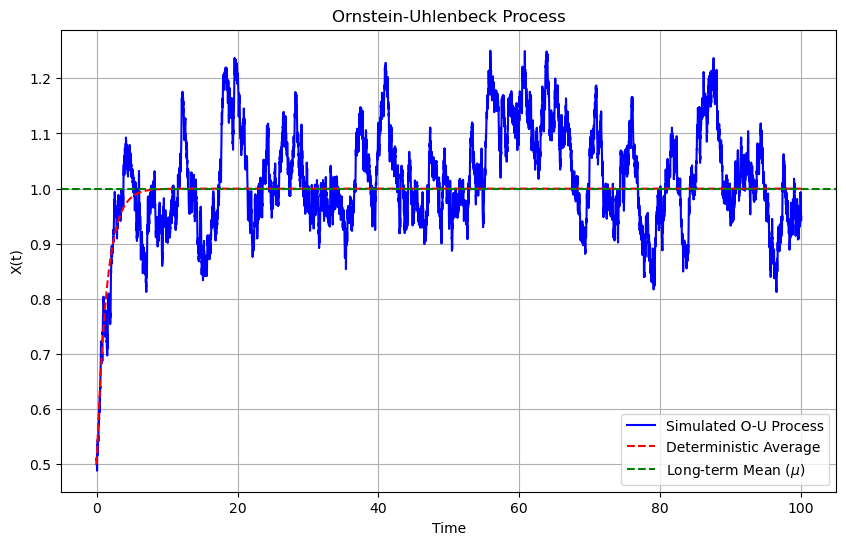

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from functions import *


# Parameters for the Ornstein-Uhlenbeck process
theta = 0.7     # rate of mean reversion
mu = 1.0        # long-term mean
sigma = 0.1     # volatility
X0 = 0.5        # initial value
T = 100          # total time
dt = 0.01       # time step
n_steps = int(T / dt)  # number of steps

# Time array
time = np.linspace(0, T, n_steps)

# Initialize the array to store the process values
X = np.zeros(n_steps)
X[0] = X0

# Simulate the Ornstein-Uhlenbeck process
for t in range(1, n_steps):
    dW = np.random.normal(0, np.sqrt(dt))  # Brownian motion increment
    X[t] = X[t-1] + theta * (mu - X[t-1]) * dt + sigma * dW

# Analytical solution for comparison
X_analytical = X0 * np.exp(-theta * time) + mu * (1 - np.exp(-theta * time))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(time, X, label="Simulated O-U Process", color="blue")
plt.plot(time, X_analytical, label="Deterministic Average", color="red", linestyle='dashed')
plt.axhline(mu, color="green", linestyle="--", label="Long-term Mean ($\mu$)")
plt.title("Ornstein-Uhlenbeck Process")
plt.xlabel("Time")
plt.ylabel("X(t)")
plt.legend()
plt.grid(True)
plt.show()

# 2 Project Overview


## 2.1 Focus Areas 
- **Group 1's Task:** Develop a metric for **mean reversion**.  
- **Our Task:** Instead of focusing on mean reversion, we will implement **predefined tests** to determine whether our dataset exhibits a trend within a given time window.  

## 2.2 Approach  
1. **Trend Detection:** Apply statistical tests to classify intervals as trending or non-trending.  
2. **Detrending Methods:**  
   - Implement a **statistical approach** based on test results.  
   - Compare it to a more **empirical method** that does not rely on formal statistical tests.  
3. Use **Group 1's mean reversion metric** to assess and validate the effectiveness of our detrending methods

Before diving into our analysis, we will preprocess our dataset to ensure data quality and consistency.  

# 3 Data Preprocessing

## 3.1 Filtering the Signal

Before applying each test, we first **filter the signal**.  

To achieve this, we implemented a function that removes a fraction of high-frequency components. This is done by discarding a selected portion of the **Area Under the Curve (AUC)** of the power spectrum. In our case, we discard **3% (0.03) of the total power**.  

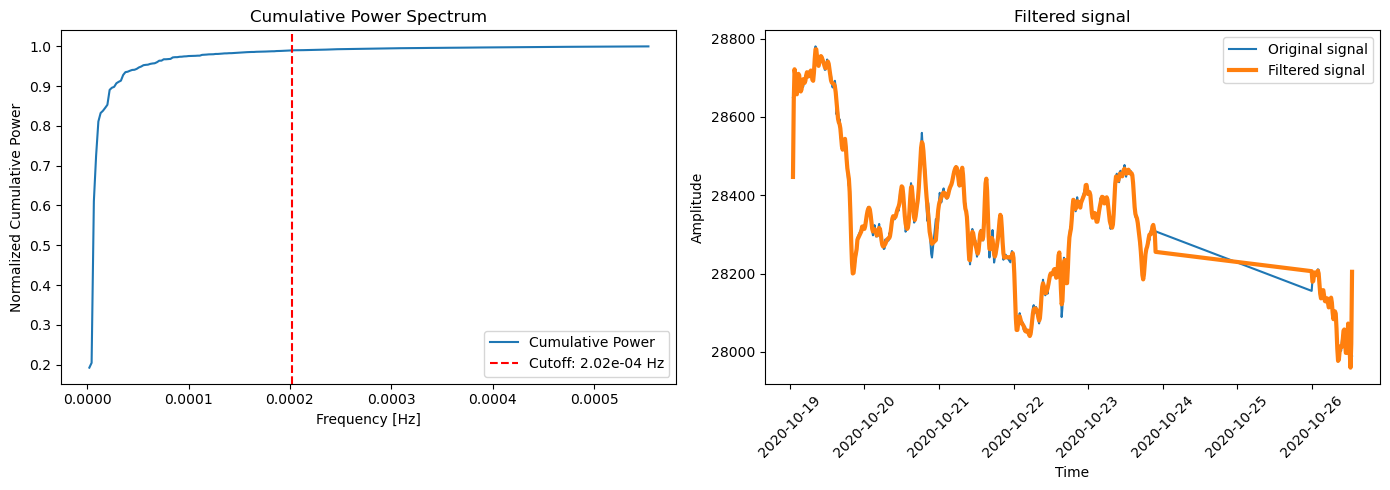

In [39]:
# Import and clean data
from functions import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftfreq
from hurst import compute_Hc

# Load the data
df, close_data = import_data("data_M15/DJ_M15_202009240845_202411131015.csv") 

# Select the data range for analysis
t_min = 1500
t_max = 2000

# Extract the signal and its datetime index
sig = close_data[t_min:t_max]
datetime_index = close_data.index[t_min:t_max]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

#Call the function and pass the first axis (axes[0]) for the spectrum plot
filtered_sig_series = filter_signal_by_auc(
    sig, 
    datetime_index, 
    time_step=15*60, 
    discard_fraction=0.01, 
    ax=axes[0]
)

#Plot the original and filtered signal on the second axis (axes[1])
axes[1].plot(datetime_index, sig, label='Original signal')
axes[1].plot(datetime_index, filtered_sig_series, linewidth=3, label='Filtered signal')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Amplitude')
axes[1].legend(loc='best')
axes[1].set_title("Filtered signal")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4 Statistical Tests for Trend Detection

The removal of the trend from the data is performed by applying an algorithm to them. <br>
In this project we were asked for an empirical implementation of such an algorithm. In fact, there are countless examples in the literature that show the difficulties and precautions needed in modeling this type of data (e.g. https://doi.org/10.2307/1183489), and therefore in using rigorous approaches.<br>
By not being rigorous, the algorithm we will build will alter, at least partially, the information contained in the data. Therefore, to minimize this modification, the processing is applied only to the regions where there appears to be a trend. These regions must therefore be identified.<br>
To this end, one of the metrics developed by group 1 could be used, but they depend on the efficiency with which the data are detrended. Predefined tests are then used, since this is a preliminary procedure that will then be strengthened by the feedback mechanism granted by applying the metric of group 1, at the end of the work, to the detrended data.

#### **Hurst exponent**

The **Hurst exponent**, denoted as $ H $, is a statistical measure used to evaluate the long-term memory of time series data. It helps in understanding the behavior of financial time series, indicating whether they are mean-reverting, trending, or following a random walk.

#### Mathematical Background

The Hurst exponent is defined mathematically in terms of the rescaled range $ R(n) $ and standard deviation $ S(n) $ of the time series:

$$
\mathbb{E}\left[\frac{R(n)}{S(n)}\right] = C n^H \quad \text{as } n \to \infty
$$


Where:
- $ R(n) $: The range of the first $ n $ cumulative deviations from the mean.
- $ S(n) $: The standard deviation of the first $ n $ observations.
- $ C $: A constant.


#### Interpretation of Hurst Exponent Values

The value of the Hurst exponent ranges from 0 to 1 and can be interpreted as follows:

- *$$ H < 0.5 $$* Indicates **mean-reverting behavior**. This suggests that the time series tends to revert back to its average over time. For example, a stock price that oscillates around its mean without sustaining a prolonged trend would exhibit this behavior.
  
- *$$ H = 0.5 $$* Suggests that the time series behaves like a **Geometric Brownian Motion**, implying no clear trend and resembling a random walk.

- *$$ H > 0.5 $$* Indicates **trending behavior**. In this case, high values are likely to be followed by more high values, suggesting persistence in the direction of movement.

## 4.1 First Approach: Detrending using Hurst Exponent

We tried to apply this metric in two ways:

1. determine the intervals where data seem to be trending (discussed later)

2. find an "optimal" interval to perform rolling means (a possible strategy to remove trends from the data is to perform rolling means using a certain window with, and then subtracting those values to the actual data).

Let's analyse this approaches:

##### Approach 2.
The idea is that there will be an optimal frequency (and corresponding timewindow) which better describes the trend.

Detrending via rolling mean using this window would then provide a minima in the Hurst exponent.


We then tried to compute a "rolling version" of H over a range of windows.

In [20]:
filtered_sig=filtered_sig_series
H_rollv=[]
H_v=[]
x=np.linspace(2,300)
for window in x:
    filtered_new=(filtered_sig-filtered_sig.rolling(window=int(window)).mean()) #Rolling mean over window
    filtered_sig_no_nan = filtered_new[~np.isnan(filtered_new)] #Remove NaN values
    H_roll, c, data=compute_Hc(filtered_sig_no_nan,kind='random_walk', simplified=False) #Compute Hurst exponent
    H, c, data = compute_Hc(filtered_sig,kind='random_walk', simplified=False)
    H_rollv.append(H_roll)

Minimum for x = 8.081632653061224 
H_min = 0.3714390995286466


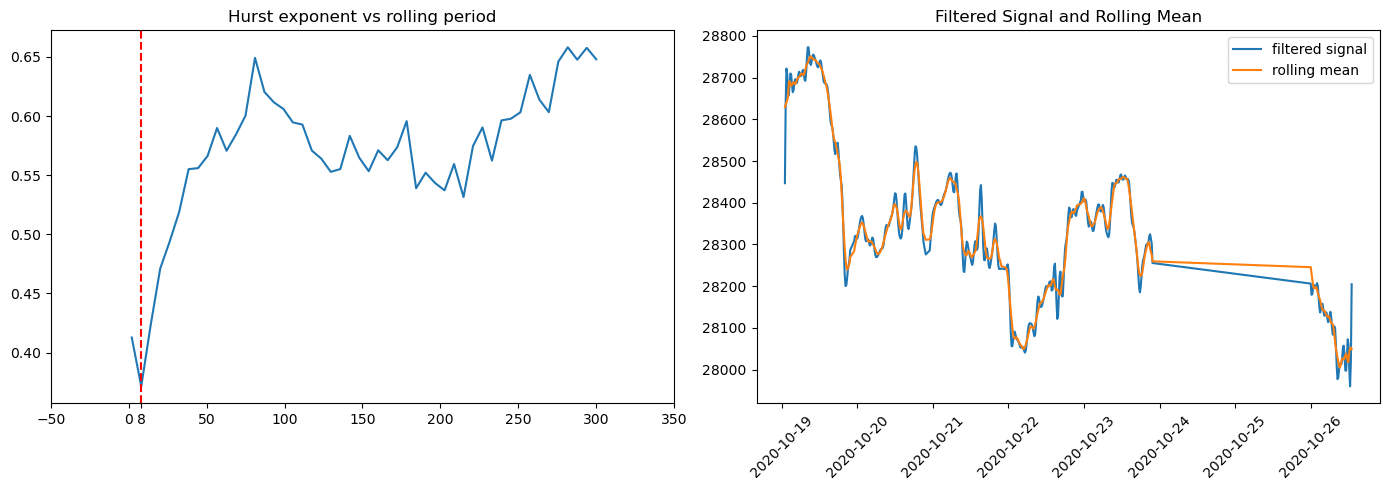

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))


#PLOT1: Hurst exponent vs rolling period (Left Axis: axes[0])

axes[0].plot(x, H_rollv)
axes[0].set_title("Hurst exponent vs rolling period")

# Find the x-value and y-value corresponding to the minimum of H_rollv
xmin = x[np.argmin(H_rollv)]
Hmin = H_rollv[np.argmin(H_rollv)]

print("Minimum for x =", xmin, "\nH_min =", Hmin) # Print the minimum point
axes[0].axvline(x=xmin, color='red', linestyle='--') # Plot a red vertical line at x = xmin

#Set the new x-ticks
current_ticks = axes[0].get_xticks()
new_ticks = np.append(current_ticks, xmin)
axes[0].set_xticks(new_ticks)


# PLOT 2: Filtered signal and rolling mean (Right Axis: axes[1])
axes[1].plot(filtered_sig, label="filtered signal")
axes[1].plot(filtered_sig.rolling(window=int(xmin), min_periods=1, center=True).mean(), label="rolling mean")
axes[1].set_title("Filtered Signal and Rolling Mean")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

Unfortunately the idea is not very effective, since the Hurst Exponent is higly sensible on the small oscillation of the data of the data, as we will see next.

##### Approach 1.

We found out that the Hurst exponent can't be considered as a reliable measure of mean revertness. In fact it measures long term behaviors of the time series, but these don't necessary concide with mean-revertness.

An example is provided below, where various sinosoidal timeseries have been generated and trend/ noise has been added to some of them.
Finally the relative Hurst exponents have been computed over a timewindow of N=5000 timesteps, but we can see that there is almost no difference in H before and after detrending.

This may be due, as before, by H focusing on the noise rather than the general trend.

We must also consider that we need enough data points to reliably estimate the Hurst exponent. In fact Hurst’s analysis strongly depend on the length of the time series ([Coronado Jiménez and Carpena, 2005](https://doi.org/10.1007/s10867-005-3126-8)).


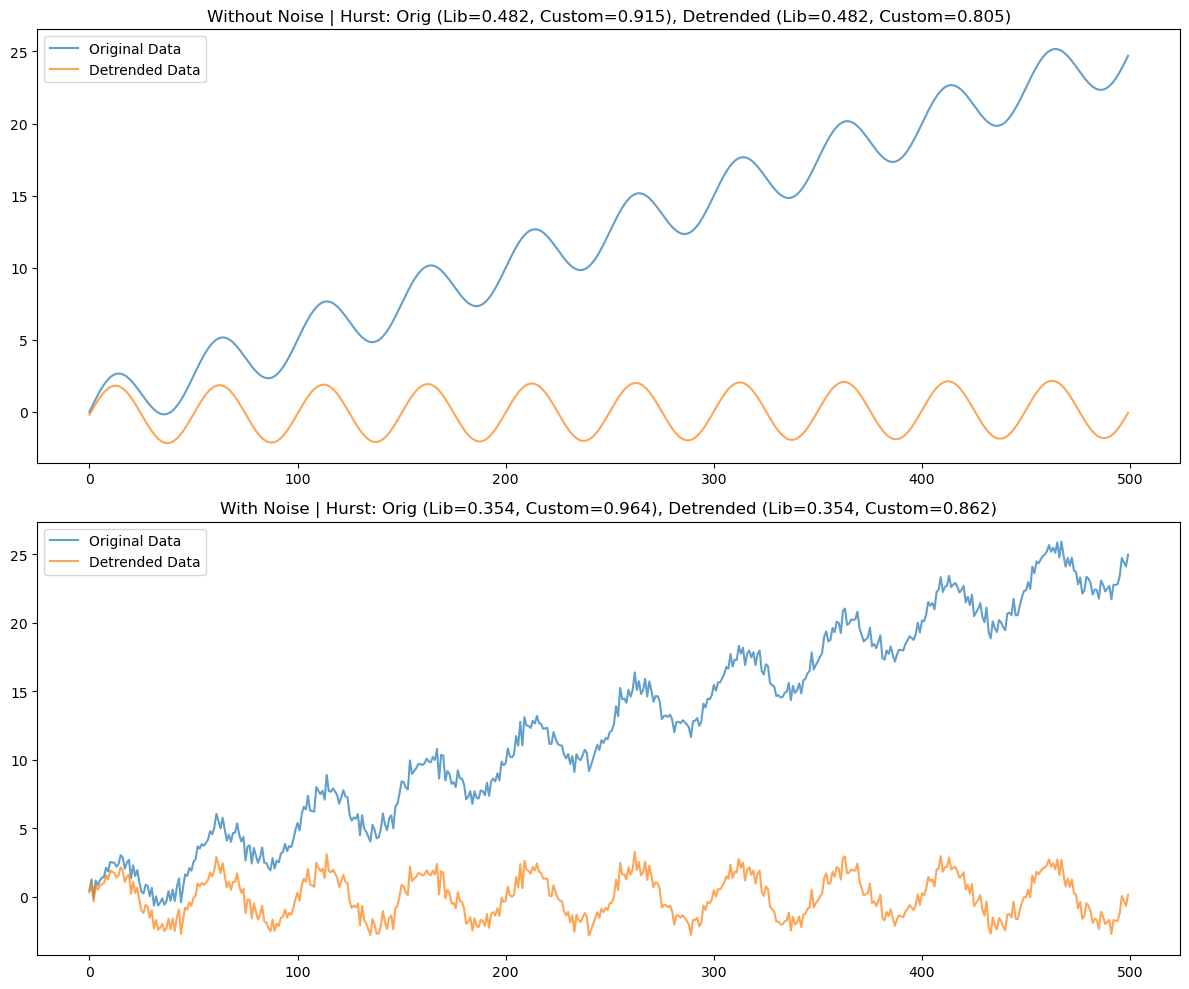

In [22]:
#Trial for final explaination

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from hurst import compute_Hc

def hurst_exponent(time_series, min_window=10, max_window=100):
    """
    Estimate the Hurst exponent of a time series using Rescaled Range (R/S) analysis.

    Parameters:
    - time_series: array-like, the time series to analyze.
    - min_window: int, minimum segment size (m).
    - max_window: int, maximum segment size (m).

    Returns:
    - H: float, the estimated Hurst exponent.
    """
    N = len(time_series)
    rs_values = []
    window_sizes = []

    for window_size in range(min_window, min(max_window, N // 2)):
        window_sizes.append(window_size)
        num_windows = N // window_size
        rs_for_window = []

        for i in range(num_windows):
            # Extract the window
            segment = time_series[i * window_size:(i + 1) * window_size]

            # Calculate mean and cumulative deviation
            mean = np.mean(segment)
            cumulative_deviation = np.cumsum(segment - mean)

            # Calculate range (R) and standard deviation (S)
            R = np.max(cumulative_deviation) - np.min(cumulative_deviation)
            S = np.std(segment)

            if S > 0:
                rs_for_window.append(R / S)

        # Average R/S across all windows
        if rs_for_window:
            rs_values.append(np.mean(rs_for_window))

    # Fit a line to log-log plot to estimate H
    log_window_sizes = np.log(window_sizes)
    log_rs_values = np.log(rs_values)
    H, _ = np.polyfit(log_window_sizes, log_rs_values, 1)

    return H

def generate_series(n, trend_slope=0.1, oscillation_amplitude=1.0, noise_level=0.0):
    t = np.arange(n)
    trend = trend_slope * t
    oscillation = oscillation_amplitude * np.sin(2 * np.pi * t / 50)
    noise = np.random.normal(scale=noise_level, size=n)
    return trend + oscillation + noise

def linear_detrend(series):
    t = np.arange(len(series))
    slope, intercept, _, _, _ = linregress(t, series)
    return series - (slope * t + intercept)

def analyze_series(data, title_prefix, ax):
    hurst_lib, _, _ = compute_Hc(data, kind='random_walk', simplified=False)
    hurst_custom = hurst_exponent(data)
    detrended_data = linear_detrend(data)
    hurst_lib_detrended, _, _ = compute_Hc(detrended_data, kind='random_walk', simplified=False)
    hurst_custom_detrended = hurst_exponent(detrended_data)

    ax.plot(data, label="Original Data", alpha=0.7)
    ax.plot(detrended_data, label="Detrended Data", alpha=0.7)
    ax.legend()
    ax.set_title(f"{title_prefix} | Hurst: Orig (Lib={hurst_lib:.3f}, Custom={hurst_custom:.3f}), "
                 f"Detrended (Lib={hurst_lib_detrended:.3f}, Custom={hurst_custom_detrended:.3f})")

np.random.seed(42)
N = 500 

data_clean = generate_series(N, trend_slope=0.05, oscillation_amplitude=2.0, noise_level=0.0)
data_noisy = generate_series(N, trend_slope=0.05, oscillation_amplitude=2.0, noise_level=0.5)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

analyze_series(data_clean, "Without Noise", ax=axes[0])
analyze_series(data_noisy, "With Noise", ax=axes[1])

plt.tight_layout()
plt.show()

## 4.2 Alternative Approach: Mann-Kendall Test
The M-K test is a non parametric test to assess monotonic trends.
It is a hypothesis test:


*   H<sub>0</sub>: There is no monotonic trend in the data. The observations x<sub>1</sub>, x<sub>2</sub>, ..., x<sub>n</sub> are independent and randomly ordered over time.
*   H<sub>a</sub>:There is a monotonic trend in the data.

The test computes the difference between each pair of data points and counts how many of these differences are positive or negative, so it evaluates if there are more increasing or decreasing values in the data. When applied to a timeseries the statistic of the test is defined as:

$$
S = \sum_{i=1}^{n-1} \sum_{j=i+1}^{n} \text{sgn} (x_j - x_i)
$$
<br>
where:

$$
\text{sgn} (x_j - x_i) =
\begin{cases}
+1 & \text{if } (x_j - x_i) > 0 \\
0 & \text{if }(x_j - x_i) = 0 \\
-1 & \text{if }(x_j - x_i) < 0
\end{cases}
$$

<br>
and n is the sample size.
To evaluate the significance of 𝑆, the 𝑍 statistic is computed since for $n \geq 10$, S can be approximated by a normal distribution, allowing the use of a z-score:
<br>

$$
Z =
\begin{cases}
\frac{(S - 1)}{\sigma_s} & \text{if } S > 0 \\
0 & \text{if } S = 0 \\
\frac{(S + 1)}{\sigma_s} & \text{if } S < 0
\end{cases}
$$
<br>
where:

$$
\sigma_s = \sqrt{\frac{n(n-1)(2n+5) - \sum_{j=1}^{q} t_j (t_j - 1)(2t_j + 5)}{18}}
$$
<BR>
in which the first term of the difference is the variance of 𝑆 assuming no ties, while the sum accounts for ties, reducing the variance, since tied observations contribute less to a trend; *q* is the number of values that have ties, t<sub>j</sub> how many times the j-th value is repeated.<br>

If Z<Z<sub>α/2</sub> with a significance level α, then there doesn’t exist trend in the timeseries. (https://doi.org/10.2307/1907187, doi:10.1017/S0020268100013019)

However, as H<sub>0</sub> states, the test is sensitive to autocorrelation, so Hamed and Rao developed a new version of the test to account for autocorrelation. According to the idea that when the data are autocorrelated the variance is underestimated, they substitute *n* with an effective length, thus inflating the variance of the test statistic 𝑆 (https://doi.org/10.1016/S0022-1694(97)00125-X). However, when a trend is present, a powerful estimation of the autocorrelation fails, so Yue and Wang developed another version of the test: if the autocorrelation is estiamted from the detrended series, the effective sample size can still effectively reduce the influence of serial correlation on the MK test (https://doi.org/10.1023/B:WARM.0000043140.61082.60).
<br>All these versions (and many more) are implemented in the 'pyMannKendall' python package (https://doi.org/10.21105/joss.01556).<br><br>
Let's try this test and see if its results seem reasonable.

2020-09-24 08:45:00
0
2020-10-23 15:00:00


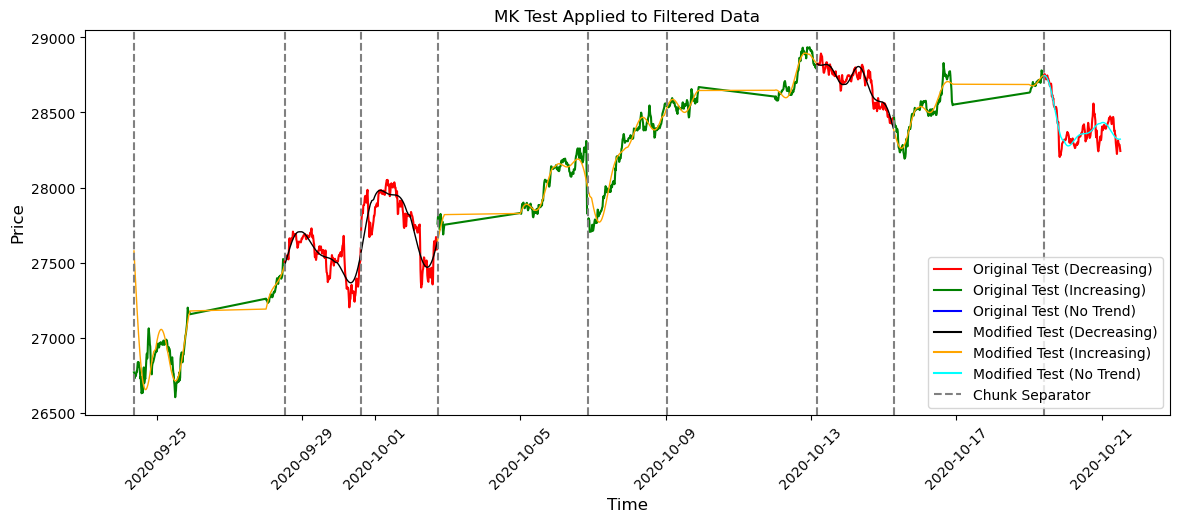

In [6]:
from functions import interval_selector
start_index, end_index = interval_selector(0,20,df)
original_test, modified_test = mann_kendall(chunk_size=192, start_index=start_index, end_index=end_index, df=df,plotting=True)

So it looks promising.
Let's try to assess its stability: we apply the test to a rolling window with a pace much bigger than 1, to then iterate this calculation gradually decreasing it. If it is stable enough we expect no abrupt changes in the results of the test computed in this way.

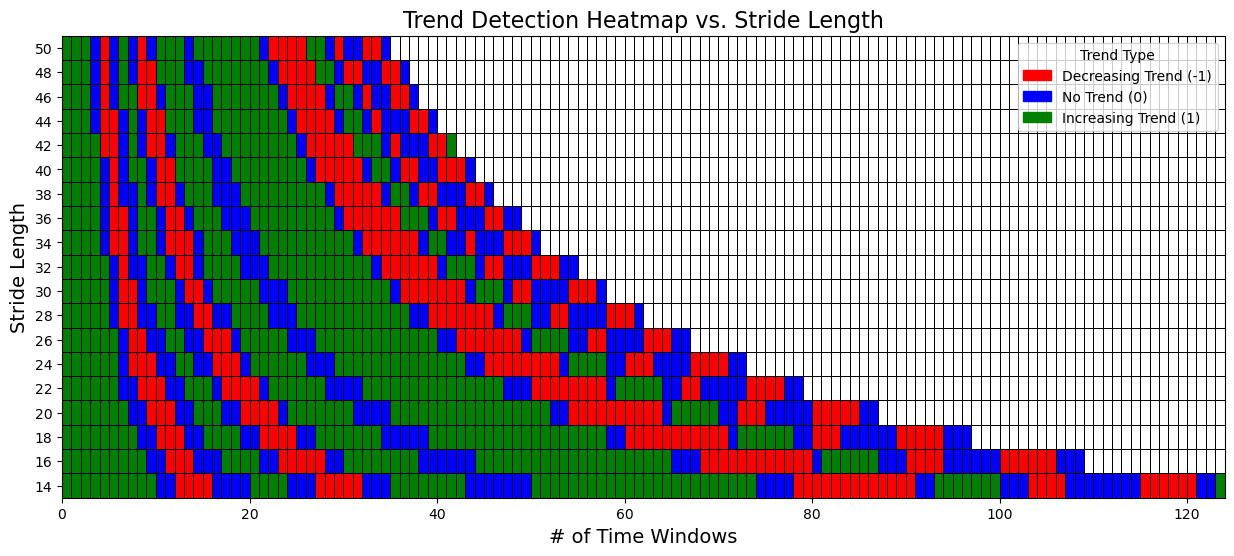

In [8]:
#from functions import heatmap
from functions import heatmap
stride_values = list(range(14, 52, 2))
chunk_size=192
heatmap(stride_values, chunk_size, start_index, end_index, df)

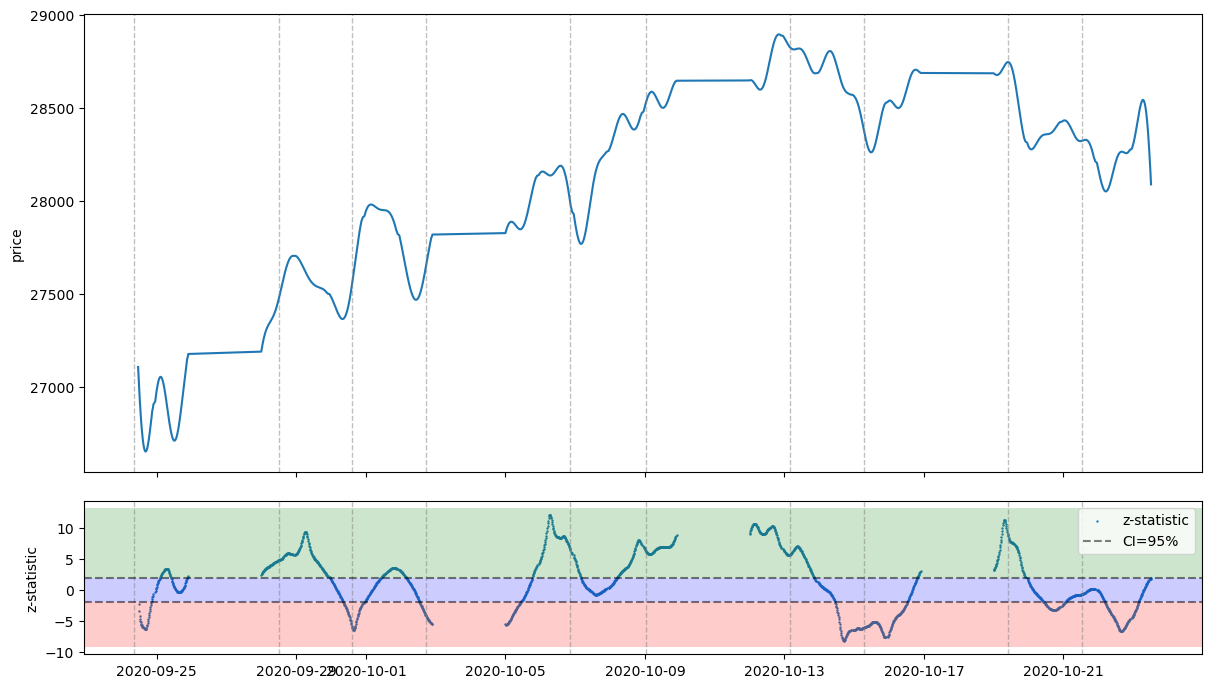

In [9]:
#from functions import z_statistic
z_statistic(chunk_size, start_index, end_index, df, gif=False)

![An example of trending asset](Fig/Z-statistics.jpeg)

This plot shows that the results match the expectations: even if there are some local variations, since they are reasonable, the "global" traces convey stability.<br>
A real-life application can now be explpored: let's apply the test on a rolling basis, with the rolling stride euqal to 1:

The color code is the same of the heatmap.<br>
The 'gif==True' option creates this plot dynamically and this is the result it produces:

<img src="Fig/GIF.gif" width="1000">

Considering what has been said so far, we believe that the Mann Kendall test is reliable enough to determine the portions of the time series where the de-trending algorithm should be applied, preliminarily at least.

# 5 De-trending Algorithms

## 5.1 Rolling Mean Method

We now try to detrend the data by subtracting rolling means.


In particular we find an optimal timewindow w which corresponds to a given cutoff on the cumulative spectrum (in our case we chose 10%)

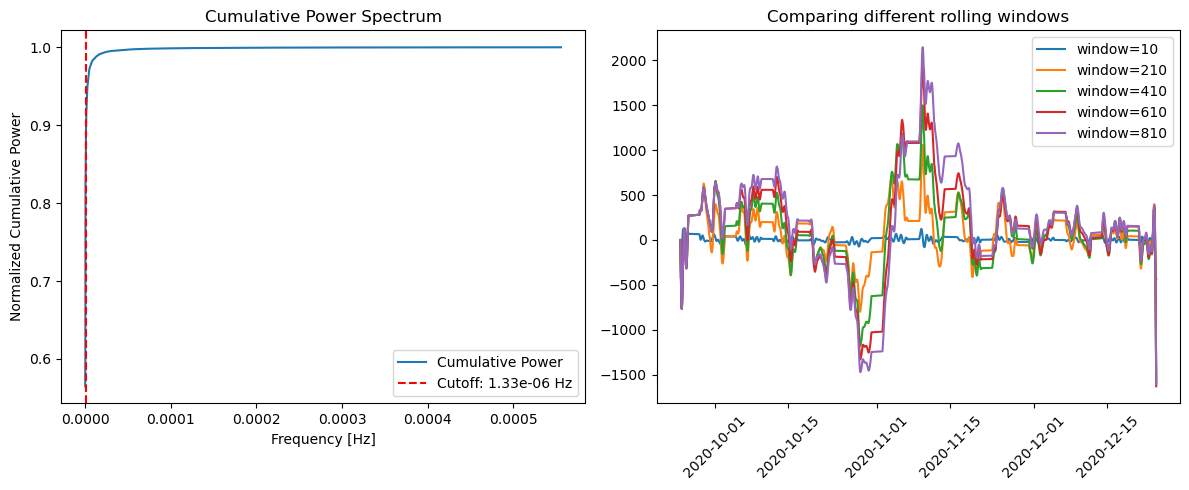

In [60]:
from functions import *
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
#file="data_M15/DAX_M15_202005242300_202411131015.csv"
file="data_M15/DJ_M15_202009240845_202411131015.csv"
df, close_data = import_data(file)

# We consider a 2 day interval
#t_min = pd.to_datetime('2020.05.25 09:15:00')
t_min = pd.to_datetime('2020.09.24 08:45:00')
t_min = close_data.index.get_loc(t_min)

#t_max = pd.to_datetime('2020.08.25 09:15:00')
t_max = pd.to_datetime('2020.12.24 08:45:00')
t_max = close_data.index.get_loc(t_max)

# Extract the signal and its datetime index
sig = close_data[t_min:t_max]
datetime_index = close_data.index[t_min:t_max]

# Get the filtered signal quietly
filtered_sig_series = filter_signal_by_auc(sig, datetime_index, time_step=15*60, discard_fraction=0.01, ax=None)
filtered_sig = filtered_sig_series

# Get the cutoff period -> frequency
cutoff = 1 / (get_period(sig, 0.01) * 900)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

#PLOT 1: Spectrum Plot (Left Axis)
filter_signal_by_auc(sig, datetime_index, time_step=15*60, discard_fraction=0.1, ax=axes[0])

# PLOT 2: Rolling Windows (Right Axis) 
for w in range(10, 1000, 200):
    axes[1].plot(filtered_sig.index, filtered_sig - filtered_sig.rolling(window=w, min_periods=1, center=False).mean(), label=f"window={w}")

axes[1].set_title("Comparing different rolling windows")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.1.1 Determining the Best Window
`get_period` is a function to find an optimal timewindow w which corresponds to a given cutoff on the cumulative spectrum; check it in the `functions.py` file.

In [31]:
w=get_period(filtered_sig)
print("Rolling mean optimal period: ",w)

Rolling mean optimal period:  972


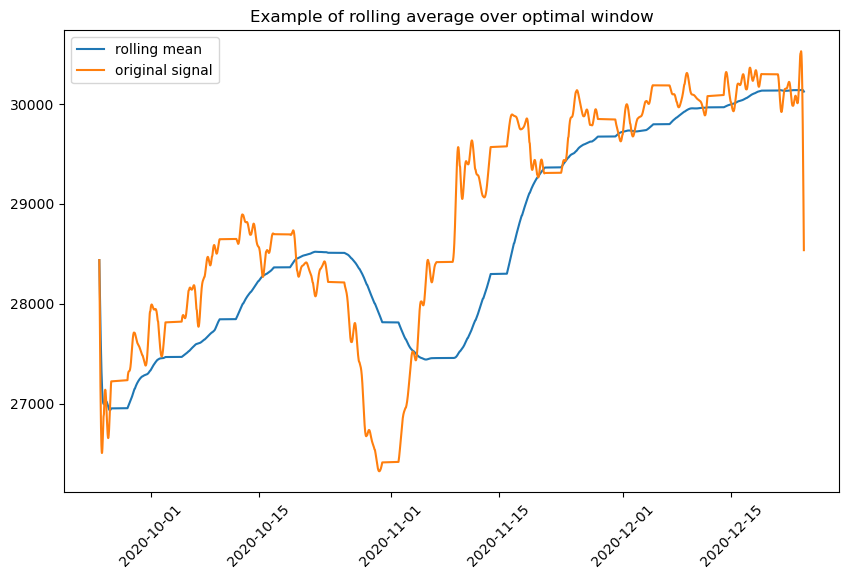

In [32]:
plt.figure(figsize=(10,6))
plt.plot(filtered_sig.rolling(window=int(w), min_periods=1, center=False).mean(), label="rolling mean")
plt.plot(filtered_sig,label="original signal")
plt.xticks(rotation=45)
plt.title("Example of rolling average over optimal window")
plt.legend()
plt.show()

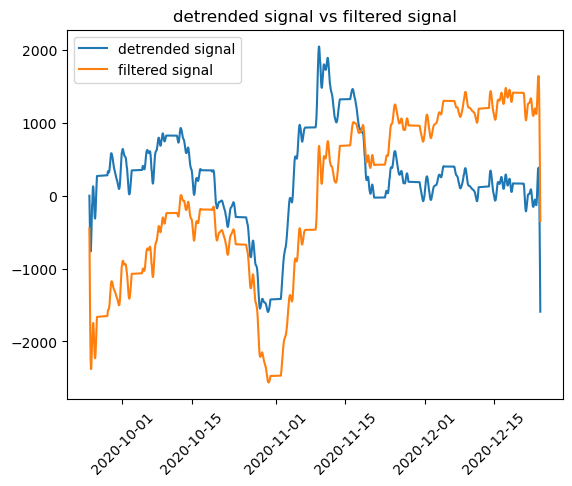

In [30]:
plt.plot(filtered_sig-filtered_sig.rolling(window=1000, min_periods=1, center=False).mean(),label="detrended signal")
plt.plot(filtered_sig-np.mean(filtered_sig), label='filtered signal')
plt.xticks(rotation=45)
plt.title("detrended signal vs filtered signal")
plt.legend()
plt.show()

### 5.1.2 Validation on Toy Model

We try the algorithm on the same data generated to test the Hurst exponent

Period:  71


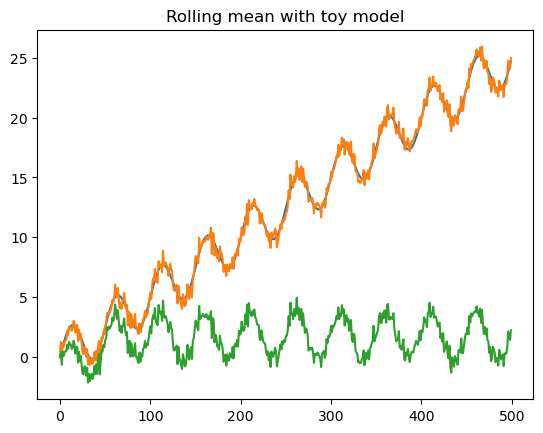

In [17]:
#Trial for final explaination

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from hurst import compute_Hc

def generate_series(n, trend_slope=0.1, oscillation_amplitude=1.0, noise_level=0.0):
    t = np.arange(n)
    trend = trend_slope * t
    oscillation = oscillation_amplitude * np.sin(2 * np.pi * t / 50)
    noise = np.random.normal(scale=noise_level, size=n)
    return trend + oscillation + noise

def linear_detrend(series):
    t = np.arange(len(series))
    slope, intercept, _, _, _ = linregress(t, series)
    return series - (slope * t + intercept)

def analyze_series(data, title_prefix):
    hurst_lib, _, _ = compute_Hc(data, kind='random_walk', simplified=False)
    hurst_custom = hurst_exponent(data)
    detrended_data = linear_detrend(data)
    hurst_lib_detrended, _, _ = compute_Hc(detrended_data, kind='random_walk', simplified=False)
    hurst_custom_detrended = hurst_exponent(detrended_data)

    plt.figure(figsize=(12, 6))
    plt.plot(data, label="Original Data", alpha=0.7)
    plt.plot(detrended_data, label="Detrended Data", alpha=0.7)
    plt.legend()
    plt.title(f"{title_prefix} | Hurst: Orig (Lib={hurst_lib:.3f}, Custom={hurst_custom:.3f}), "
              f"Detrended (Lib={hurst_lib_detrended:.3f}, Custom={hurst_custom_detrended:.3f})")
    plt.show()

np.random.seed(42)
N=500 #length of time series
data_clean = generate_series(N, trend_slope=0.05, oscillation_amplitude=2.0, noise_level=0.0)
plt.plot(data_clean)
data_noisy = generate_series(N, trend_slope=0.05, oscillation_amplitude=2.0, noise_level=0.5)
plt.plot(data_noisy)


w=get_period(data_noisy)
print("Period: ",w)

plt.plot(data_noisy-pd.Series(data_noisy).rolling(window=int(w), min_periods=1, center=False).mean())
plt.title("Rolling mean with toy model")
plt.show()

In this case we are able to detrend the data

## 5.2 Fit and Subtract Method (Guided by Mann-Kendall)

After exploring the rolling mean as a continuous filtering technique, we now introduce the second algorithmic approach of our study: the **Fit & Subtract** method.

Unlike the rolling mean, which is applied to the entire time series uniformly, this method is designed to intervene selectively. Our goal is to alter the original information contained in the data as little as possible. To achieve this, we rely on the Mann-Kendall test.

The algorithm operates as follows:
1. **Chunking:** the function dynamically resizes its focus window based on the current market environment—expanding during strong trends and contracting during sideways consolidation.
2. **Trend Evaluation:** The Mann-Kendall test is executed on each interval to assess statistical significance.
3. **Selective Detrending:**
   - If the test indicates the presence of a statistically significant monotonic trend (increasing or decreasing), we apply a linear regression  to the data in that window and subtract the resulting line from the signal.
   - If the test indicates "no trend", the data in that chunk is left unaltered (or simply centered around its local mean), preserving the original local dynamics.

Executing Adaptive Fit & Subtract Detrending...


/tmp/ipykernel_1875/680145656.py:263: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  x_range = pd.date_range(start=s_time, periods=len(line), freq='15T')


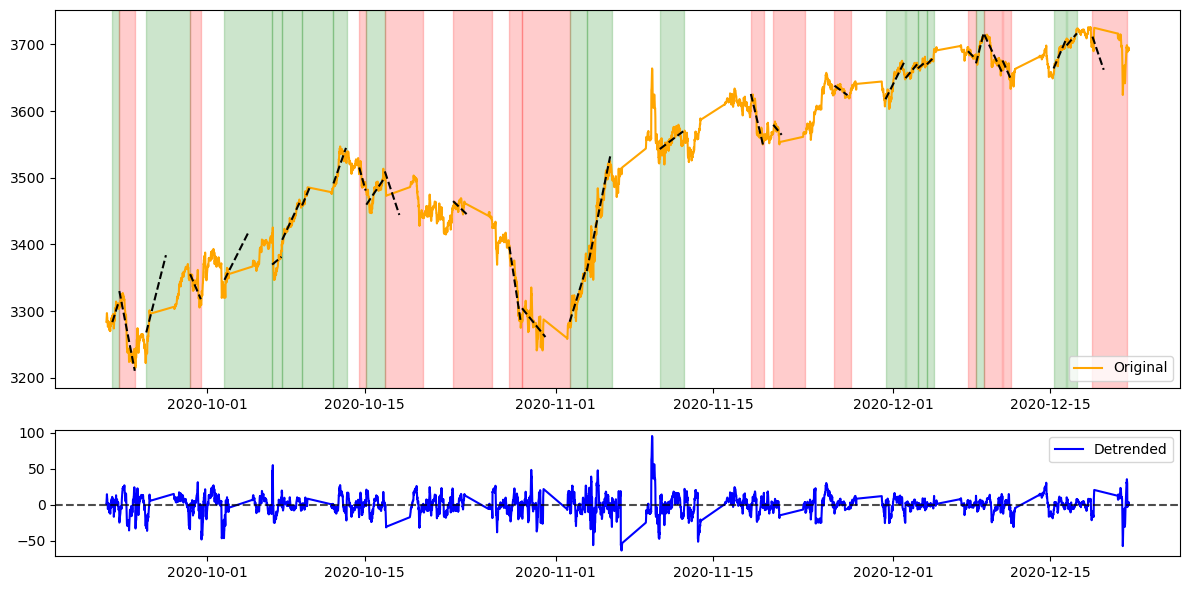

Algorithm Execution Time: 2.487472 seconds


In [72]:
# Load data and define parameters
file_path = "data_M15/SP500_M15_202009220000_202411131015.csv"

#Execute the Adaptive Fit & Subtract Algorithm
print("Executing Adaptive Fit & Subtract Detrending...")
start_exec = time.perf_counter()

detrended_full = process_time_series(
    file_path=file_path,
    base_chunk_size=50,
    start_index=t_min,
    end_index=t_max
)

end_exec = time.perf_counter()

print(f"Algorithm Execution Time: {end_exec - start_exec:.6f} seconds")

We use again the Mann-Kendall test in the detreneded series to verify that the trend has been successufly substract


In [73]:
mk_test=yue_wang_modification_test(detrended_full[0]).trend
print(mk_test)

no trend


# 6 Comparison and Evaluation

## 6.1 Quantitative Comparison (Rolling Mean vs. Fit & Subtract)

We can clearly observe a difference in the results of the two approaches.
The serie detrended with the rolling mean seem to "preserve" more the original structure of the data.

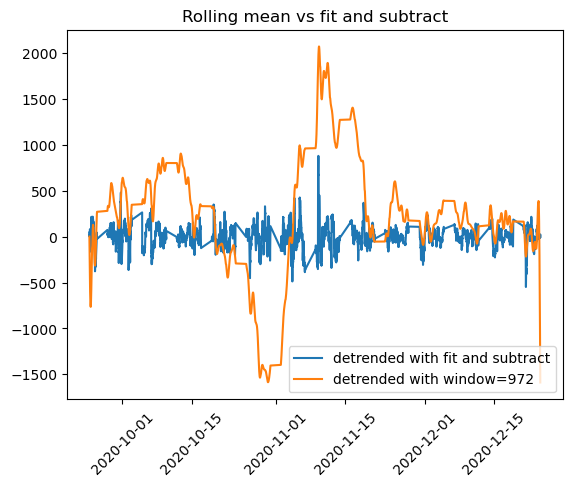

In [74]:
w=int(get_period(filtered_sig))
plt.plot(detrended, label="detrended with fit and subtract")


plt.plot(filtered_sig-filtered_sig.rolling(window=w, min_periods=1, center=False).mean(), label=f"detrended with window={w}")
plt.xticks(rotation=45)
plt.title("Rolling mean vs fit and subtract")
plt.legend()
plt.show()

We try to quantify our intuition by looking at the spectrum

## 6.2 Spectrum Analysis

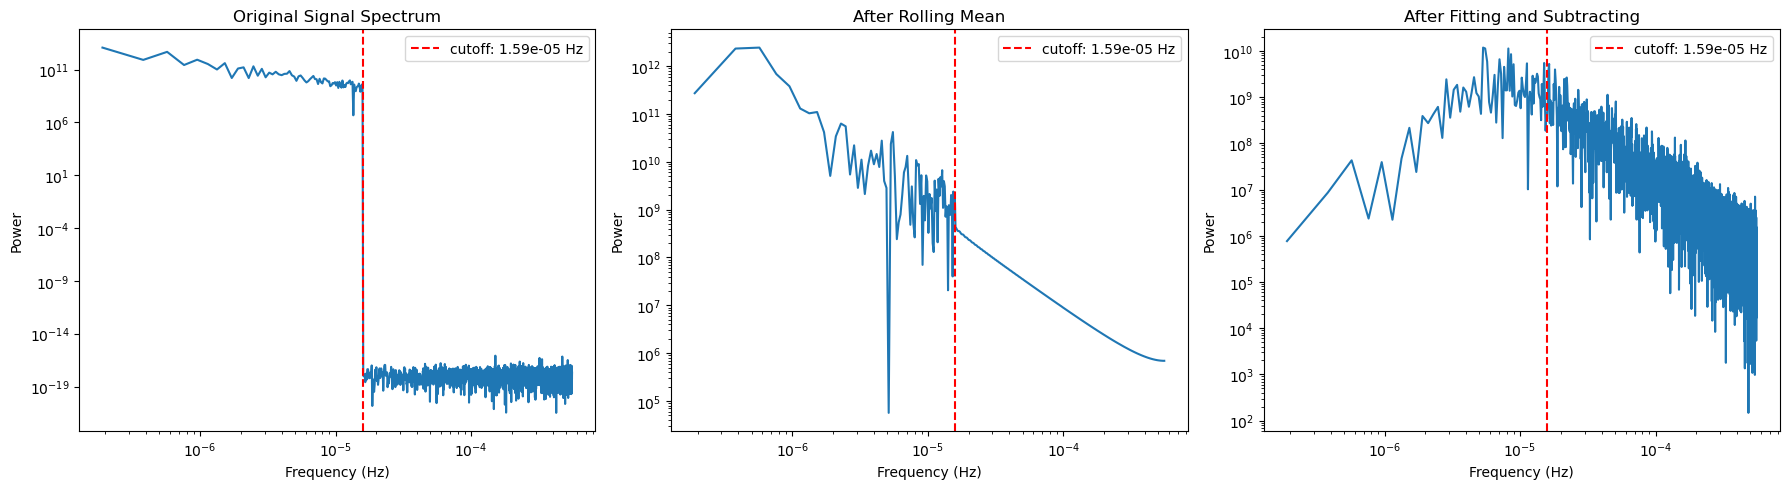

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_power_spectrum(signal, cutoff, title="Power Spectrum", ax=None):
    N = len(signal)
    time_step = 15*60  # 15 minutes in seconds
    freq = np.fft.fftfreq(N, d=time_step)  # Convert to Hz
    psd = np.abs(np.fft.fft(signal))**2  # Compute power spectral density

    # If an axis is provided, plot on it. Otherwise, create a new one (for flexibility).
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    ax.loglog(freq[freq > 0], psd[freq > 0])  
    ax.axvline(cutoff, color='r', linestyle='--', label=f'cutoff: {cutoff:.2e} Hz') 
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.legend()
    ax.set_title(title)

# Compute final_sig (assuming 'w' and 'filtered_sig' are already defined in your notebook)
final_sig = filtered_sig - filtered_sig.rolling(window=w, min_periods=1).mean()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Plot each spectrum on its respective axis
plot_power_spectrum(filtered_sig, cutoff=cutoff, title="Original Signal Spectrum", ax=axes[0])
plot_power_spectrum(final_sig, cutoff=cutoff, title="After Rolling Mean", ax=axes[1])
plot_power_spectrum(detrended, cutoff=cutoff, title="After Fitting and Subtracting", ax=axes[2])

plt.tight_layout()
plt.show()

In [25]:
print("Original period: ", get_period(filtered_sig))
print("Rolling mean: ", get_period(final_sig))
print("Fit and subtract: ", get_period(detrended))

Original period:  972
Rolling mean:  833
Fit and subtract:  21


We can observe that the period has been significantly decreased for the fit and subtract.

## 6.3 Relative Oscillatory Energy (ROE) Calculation

### 6.3.1 Overview
The **Relative Oscillatory Energy (ROE)** is a measure of how much energy a signal contains within a specific frequency band relative to its total energy. This is useful for analyzing the dominant frequency components of a time series.

### 6.3.2 Method & Steps
The **Power Spectral Density (PSD)** of the signal is estimated using **Welch’s method**, which provides a robust frequency-domain representation of the signal. The energy in a given frequency range is computed by integrating the PSD over that range.

### Steps:
1. Compute the **PSD** using Welch's method.
2. Determine the **total energy** by integrating the PSD over all available frequencies.
3. Identify the **minimum nonzero frequency** (`f_low`) and a predefined **cutoff frequency** (`cutoff`).
4. Compute the **band-limited energy** by integrating the PSD in the range `[f_low, cutoff]`.
5. Compute the **ROE** as the ratio of band-limited energy to the total energy.
6. 
### 6.3.3 Formula
Given the power spectral density $ P(f) $, the ROE is defined as:

$$
ROE = \frac{\int_{f_{\text{low}}}^{f_{\text{cutoff}}} P(f) \, df}{\int_{f_{\text{min}}}^{f_{\text{max}}} P(f) \, df}
$$

where:
- $ f_{\text{low}} $ is the smallest nonzero frequency in the PSD.
- $ f_{\text{cutoff}} $ is the predefined upper bound frequency.
- $ f_{\text{min}} $ and $ f_{\text{max}} $ are the minimum and maximum frequencies in the PSD.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy import integrate

def compute_relative_oscillatory_energy(signal, fs, cutoff):
    """
    Compute the relative oscillatory energy (ROE) for a given time series using Welch's method.

    Parameters:
        signal (numpy.ndarray): 1D array containing the time series data.
        fs (float): Sampling frequency (in Hz).
        cutoff (float): Upper bound of the frequency band of interest.

    Returns:
        roe (float): Relative oscillatory energy.
        f (numpy.ndarray): Array of frequency bins.
        Pxx (numpy.ndarray): Estimated power spectral density corresponding to f.
    """
    # Compute the PSD using Welch's method
    nperseg = min(256, len(signal))
    f, Pxx = welch(signal, fs=fs, window='hann', nperseg=nperseg)

    # Define the lower bound as the minimum nonzero frequency
    f_low = np.min(f[f > 0])  # Smallest nonzero frequency

    # Total energy is the integral of the PSD over all frequencies.
    total_energy = np.trapz(Pxx, f)

    # Energy in the desired frequency band [f_low, cutoff]
    idx_band = np.logical_and(f >= f_low, f <= cutoff)
    band_energy = np.trapz(Pxx[idx_band], f[idx_band])

    roe = band_energy / total_energy if total_energy > 0 else np.nan
    return roe, f, Pxx

# Example usage
fs = 1 / (15 * 60)  # Sampling frequency (Hz), assuming a time step of 15 minutes

roe_original, f, Pxx = compute_relative_oscillatory_energy(filtered_sig, fs, cutoff)
roe_rolling, f, Pxx_rolling = compute_relative_oscillatory_energy(final_sig, fs, cutoff)
roe_detrended, f, Pxx_detrended = compute_relative_oscillatory_energy(detrended, fs, cutoff)

print(f"ROE (Original Signal): {roe_original:.4f}")
print(f"ROE (After Rolling Mean): {roe_rolling:.4f}")
print(f"ROE (After Detrending): {roe_detrended:.4f}")

ROE (Original Signal): 0.5664
ROE (After Rolling Mean): 0.5695
ROE (After Detrending): 0.3984


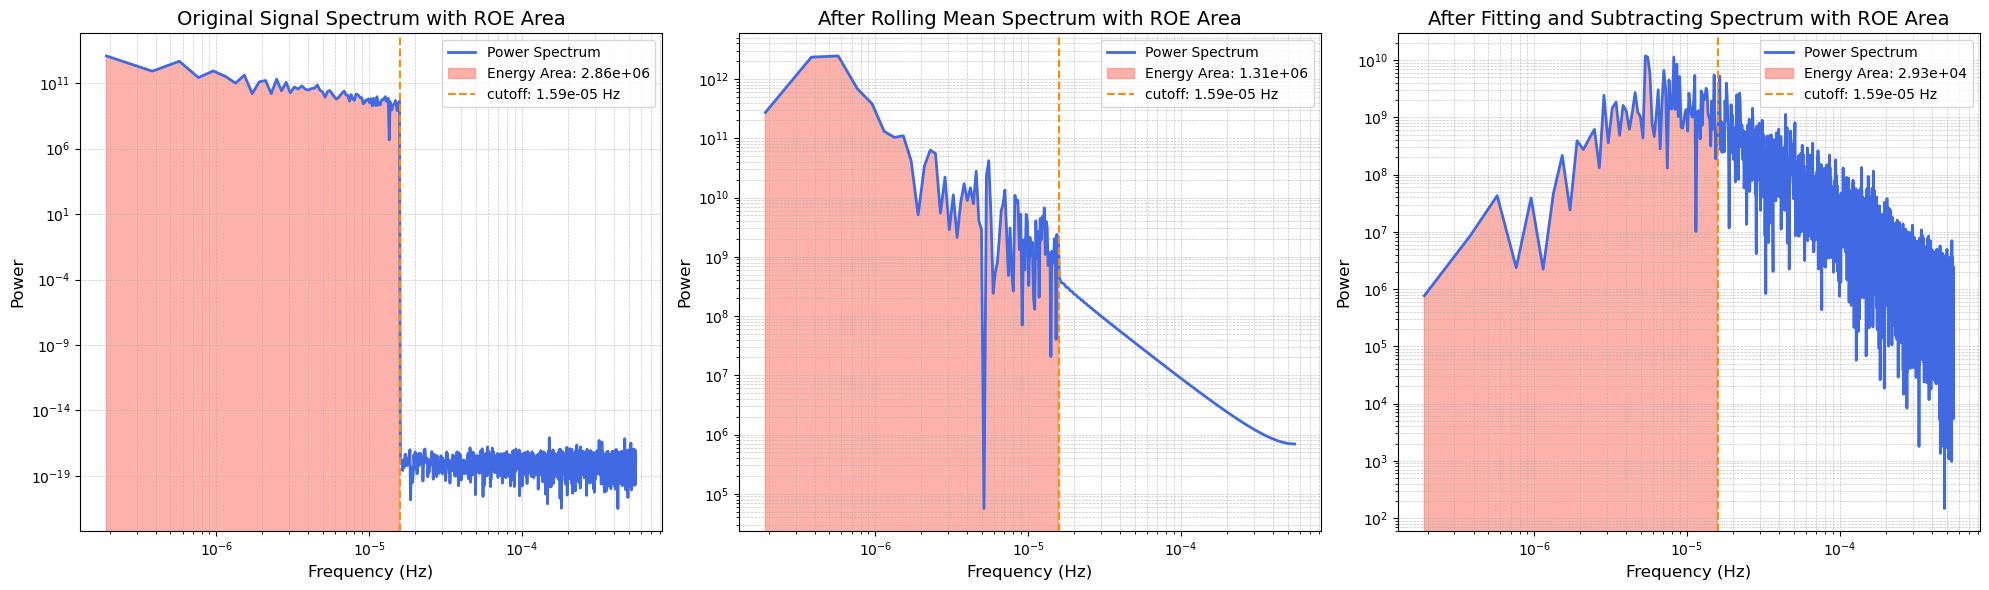

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def plot_power_spectrum_with_area(signal, fs, cutoff, title="Power Spectrum", ax=None):
    N = len(signal)
    freq = np.fft.fftfreq(N, d=1/fs)  # Frequencies corresponding to the FFT
    Pxx = np.abs(np.fft.fft(signal))**2  # Power spectral density (FFT)

    # Only positive frequencies
    positive_freq_idx = freq > 0
    f = freq[positive_freq_idx]
    Pxx = Pxx[positive_freq_idx]

    # Area under the curve between f_low and cutoff
    f_low = np.min(f[f > 0])  # Smallest nonzero frequency
    idx_band = np.logical_and(f >= f_low, f <= cutoff)
    band_energy = np.trapz(Pxx[idx_band], f[idx_band])  # Energy in the frequency band

    # If an axis is provided, plot on it. Otherwise, create a new one.
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # Plotting the power spectrum
    ax.loglog(f, Pxx, color='royalblue', label='Power Spectrum', linewidth=2)
    ax.fill_between(f[idx_band], Pxx[idx_band], color='salmon', alpha=0.6, label=f'Energy Area: {band_energy:.2e}')
    ax.axvline(cutoff, color='darkorange', linestyle='--', label=f'cutoff: {cutoff:.2e} Hz', linewidth=1.5)

    # Labels and Title
    ax.set_xlabel("Frequency (Hz)", fontsize=12)
    ax.set_ylabel("Power", fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_title(title, fontsize=14)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

fs = 1 / (15 * 60)  # Sampling frequency (in Hz), assuming a time step of 15 minutes

# Plot 1: Original signal
plot_power_spectrum_with_area(filtered_sig, fs, cutoff, title="Original Signal Spectrum with ROE Area", ax=axes[0])

# Plot 2: After rolling mean
plot_power_spectrum_with_area(final_sig, fs, cutoff, title="After Rolling Mean Spectrum with ROE Area", ax=axes[1])

# Plot 3: After detrending
plot_power_spectrum_with_area(detrended, fs, cutoff, title="After Fitting and Subtracting Spectrum with ROE Area", ax=axes[2])

# Adjust layout and display
plt.tight_layout()
plt.show()

# 7 Mean Reversion Detection

Then, the aim of this project was to "design a method that removes the trending component of an asset’s time series and reveals its mean reverting properties". So once the trend has been removed we can determine whether the timeseries exhibits mean reversion, and we can do so by applying the metric, developed in the other section of this project, that reflects the degree of mean reversion of the asset. We use this metric on the results of all the algorithms developed, to comment on their performances.


* **Data Extraction & Detrending:** We isolate a specific timeframe (the first 20 days, equivalent to `96 * 20` 15-minute intervals) and apply both the _Fit & Subtract_ and _Rolling Mean_ detrending methods;
* **Normalization (`rect`):** To make the series comparable and suitable for the metrics, the detrended signals are normalized by dividing them by their respective baseline prices (yielding the `rect` column);
* **Rolling Metrics Calculation:** Using a rolling window of 120 periods, we compute the local _Amplitude_, _Volatility_, and the _Mean Reversion Index (MRI)_ for both methods. We also calculate a rolling **Normality** score to assess the distribution of the detrended data over time.
* **Final Trend Verification:** The modified Mann-Kendall test is applied one last time to the normalized series to ensure no residual trends exist
* **Visualization (3x2 Grid):** The code generates a comparative dashboard:
    * _Top Row (Normalized Price):_ Displays the detrended, normalized signals. The background color acts as a visual indicator of the Mann-Kendall test results: _Blue_ indicates success ("no trend"), while _Red_ or _Green_ would indicate a lingering decreasing or increasing trend, respectively.
    * _Middle Row (MRI):_ Tracks the evolution of the Mean Reversion Index over time.
    * _Bottom Row (Normality):_ Tracks the rolling normality score of the signals.

This visualization allows us to definitively compare which method not only flattens the curve but also maximizes the mean-reverting characteristics of the asset.

/Users/gabrielepoccianti/Documents/LCP/Project/LCP_projects_Y7/Code/functions.py:757: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  x_range = pd.date_range(start=s_time, periods=len(line), freq='15T')


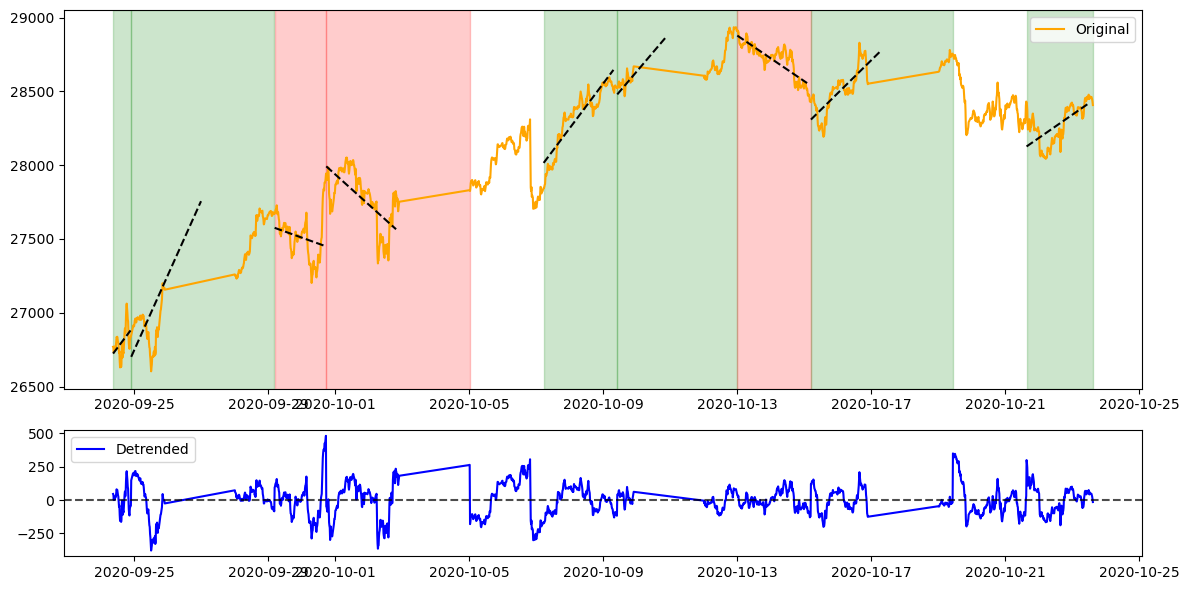

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


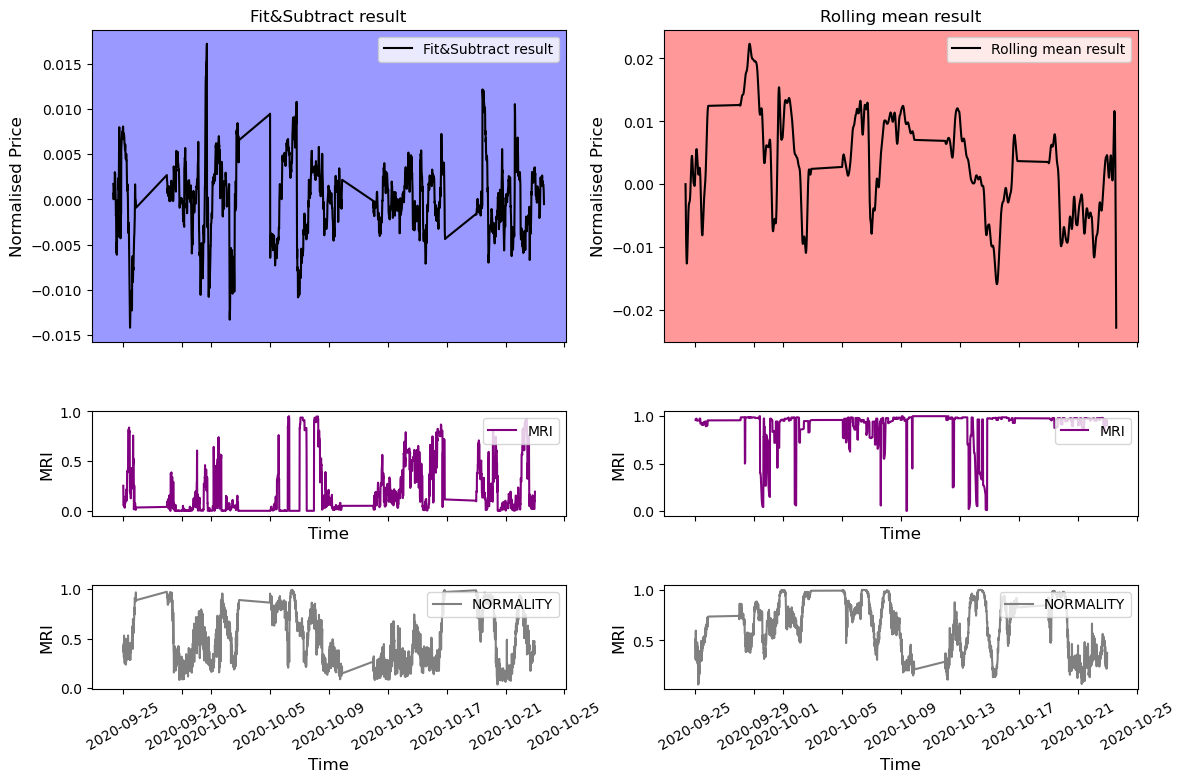

In [28]:
df,_=import_data(file)

detrended_full,_=process_time_series(
    file,
    base_chunk_size=50,
    start_index=96*0,
    end_index=96*20)

#ARIMA MRI
#fit&sub
df_fitsub=detrended_full
df_fitsub["rect"] = detrended_full/df["HA_close"][start_index:end_index]  #filtered_sig
#df_fitsub["rect"]=df_fitsub["rect"].dropna

window = 120
df_fitsub["amplitude"] = df_fitsub["rect"].rolling(window=window, center=True).apply(find_amplitudes, raw=True)
df_fitsub["volatility"] = df_fitsub["rect"].rolling(window=window, center=True).apply(volatility, raw=True)
df_fitsub["MRI"] = df_fitsub["rect"].rolling(window=window, center=True).apply(mean_revertion_index, raw=True)

#rolling mean
df_mean=df['HA_close'][start_index:end_index]
filtered_sig=filter_signal_by_auc(df_mean.values,df_mean.index, discard_fraction=0.01)
df_mean["rect"] = (filtered_sig-filtered_sig.rolling(window=get_period(filtered_sig), min_periods=1, center=False).mean())/(filtered_sig)

window = 120
df_mean["amplitude"] = df_mean["rect"].rolling(window=window, center=True).apply(find_amplitudes, raw=True)
df_mean["volatility"] = df_mean["rect"].rolling(window=window, center=True).apply(volatility, raw=True)
df_mean["MRI"] = df_mean["rect"].rolling(window=window, center=True).apply(mean_revertion_index, raw=True)

#Normal MRI
#fit&sub
df_fitsub["normality"] = df_fitsub["rect"].rolling(window = window, center = True).apply(assess_normality_rolling, raw=True, args = (int(window/8),) ) #2400 should be ok
#rolling mean
df_mean["normality"] = df_mean["rect"].rolling(window = window, center = True).apply(assess_normality_rolling, raw=True, args = (int(window/8),) ) #2400 should be ok

#plotting

data_labels = ["rect", "MRI", "normality"]
titles = ["Fit&Subtract result", "Rolling mean result"]
y_labels = ["Normalised Price", "MRI", "MRI"]
colors = ["black", "purple", "grey"]

# Apply Mann-Kendall test to df_fitsub["rect"] and df_mean["rect"]
trends = [yue_wang_modification_test(df["rect"])[0] for df in [df_fitsub, df_mean]]

# Define colors for background based on trend results
trend_colors = {
    "increasing": "green",
    "no trend": "blue",
    "decreasing": "red"
}

# Create figure with 3 rows and 2 columns
fig, ax = plt.subplots(3, 2, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
fig.tight_layout(pad=4)  # Adjust padding for better spacing

# Loop over rows (datasets, MRI, normality)
for row, label in enumerate(data_labels):
    for col, (df, title) in enumerate(zip([df_fitsub, df_mean], titles)):
        ax[row, col].plot(df[label], color=colors[row], label=title if row == 0 else label.upper())
        ax[row, col].set_title(title if row == 0 else "")
        ax[row, col].set_ylabel(y_labels[row], fontsize=12)
        ax[row, col].legend(loc='upper right')

        # Apply background color based on Mann-Kendall test for the first row (rect)
        if row == 0:
            ax[row, col].set_facecolor(trend_colors.get(trends[col], "white"))  # Default to white if unexpected value
            ax[row, col].patch.set_alpha(alpha=0.4)

        # Common settings for bottom rows
        if row > 0:
            ax[row, col].set_xlabel('Time', fontsize=12)
            ax[row, col].tick_params(axis='x', rotation=30)  # Rotate x labels for MRI & normality rows

plt.show()